In [554]:
# --- 1. Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [555]:
# --- 2. Configuration and Data Loading ---

# Define file path as a constant for easy management.
FILE_PATH = '/Users/selim/Desktop/Projects/Python Projects/Airline-Performance-Analysis/data/Airline_Delay_Cause.csv'

# Set pandas display options for better viewing in an interactive environment.
pd.set_option('display.max_columns', None)

# Load the dataset with a semicolon delimiter and robust error handling.
try:
    df = pd.read_csv(FILE_PATH, delimiter=';')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {FILE_PATH}")
    exit() # Exit if the data cannot be loaded.

Dataset loaded successfully.


In [556]:
# --- 3. Data Cleaning and Type Conversion ---

# Define the list of columns that contain inconsistent month abbreviations instead of numbers.
columns_to_clean = [
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay',
    'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'
]

# Create a mapping dictionary for Azerbaijani month abbreviations to month numbers.
# This approach is much cleaner and more maintainable than chained .replace() calls.
month_map = {
    'yan': '01', 'fev': '02', 'mar': '03', 'apr': '04', 'may': '05', 'iyn': '06',
    'iyl': '07', 'avq': '08', 'sen': '09', 'okt': '10', 'noy': '11', 'dek': '12'
}

print("\n--- Cleaning specified columns... ---")
# Loop through each column that needs cleaning.
for col in columns_to_clean:
    # First, ensure the column is a lowercase string.
    df[col] = df[col].astype(str).str.lower()
    
    # Iterate through the map and replace each month abbreviation with its number.
    for month_abbr, month_num in month_map.items():
        df[col] = df[col].str.replace(month_abbr, month_num, regex=False)
    
    # After all replacements, convert the column to a numeric type.
    # `errors='coerce'` will turn any values that failed to convert into NaN (Not a Number).
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Cleaning complete.")


--- Cleaning specified columns... ---
Cleaning complete.


In [557]:
# --- 4. Verification ---
print("\n--- Verifying Data After Cleaning ---")

# -- Check 1: DataFrame Info --
# This will confirm that the data types of the cleaned columns are now float64.
print("\n--- DataFrame Info ---")
df.info()

# -- Check 2: Sample of Cleaned Data --
# Display the first few rows to visually inspect the changes.
print("\n--- DataFrame Head ---")
display(df.head())

# -- Check 3: Null Values --
# Check if the cleaning process created any null values (e.g., from `errors='coerce'`).
# A high count might indicate a string that wasn't in our month_map.
print("\n--- Null Counts in Cleaned Columns ---")
print(df[columns_to_clean].isnull().sum())


--- Verifying Data After Cleaning ---

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149999 entries, 0 to 149998
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 149999 non-null  int64  
 1   month                149999 non-null  int64  
 2   carrier              149999 non-null  object 
 3   carrier_name         149999 non-null  object 
 4   airport              149999 non-null  object 
 5   airport_name         149999 non-null  object 
 6   arr_flights          149791 non-null  float64
 7   arr_del15            149591 non-null  float64
 8   carrier_ct           149791 non-null  float64
 9   weather_ct           149791 non-null  float64
 10  nas_ct               149791 non-null  float64
 11  security_ct          149791 non-null  float64
 12  late_aircraft_ct     149791 non-null  float64
 13  arr_cancelled        149791 non-null  float64
 14  arr_d

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,3.16,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,0.57,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,1.80,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,4.47,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,2.96,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0



--- Null Counts in Cleaned Columns ---
carrier_ct             208
weather_ct             208
nas_ct                 208
security_ct            208
late_aircraft_ct       208
arr_cancelled          208
arr_diverted           208
arr_delay              208
carrier_delay          208
weather_delay          208
nas_delay              208
security_delay         208
late_aircraft_delay    208
dtype: int64


## 1. Carrier Reliability Audit
#### Business Question: "We are renegotiating contracts with corporate partners. They want to know which airline is the most reliable. I need a ranking of carriers based on their ability to arrive on time relative to their total flight volume. Do not just give me total delay counts; I need to compare performance rates."
##### Data Requirements: carrier_name, arr_flights, arr_del15

In [558]:
# --- 1.1 Data Preparation and Aggregation ---

# Select only the columns needed for this analysis.
carrier_analysis_df = df[['carrier_name', 'arr_flights', 'arr_del15']].copy()

# Group by each carrier and sum their total flights and total delayed flights.
carrier_summary = carrier_analysis_df.groupby('carrier_name').agg(
    total_flights=('arr_flights', 'sum'),
    total_delays=('arr_del15', 'sum')
).reset_index()

In [559]:
# --- 1.2 Performance Calculation and Filtering ---

# Calculate the on-time arrival rate as a percentage for each carrier.
carrier_summary['on_time_rate'] = (
    (carrier_summary['total_flights'] - carrier_summary['total_delays']) /
    carrier_summary['total_flights'] * 100
).round(1)

# For statistical significance, filter out carriers with a low total flight volume.
MIN_FLIGHT_VOLUME = 100
carrier_summary = carrier_summary[carrier_summary['total_flights'] >= MIN_FLIGHT_VOLUME].copy()

In [560]:
# --- 1.3 Rank Carriers and Select Top Performers ---

# Sort the carriers by their on-time rate to determine the ranking.
carrier_summary = carrier_summary.sort_values('on_time_rate', ascending=False)

# Add a formal 'rank' column for clear reporting.
carrier_summary['rank'] = carrier_summary['on_time_rate'].rank(ascending=False, method='dense').astype(int)

# Select the top 10 carriers for visualization.
top_10_carriers = carrier_summary.head(10)

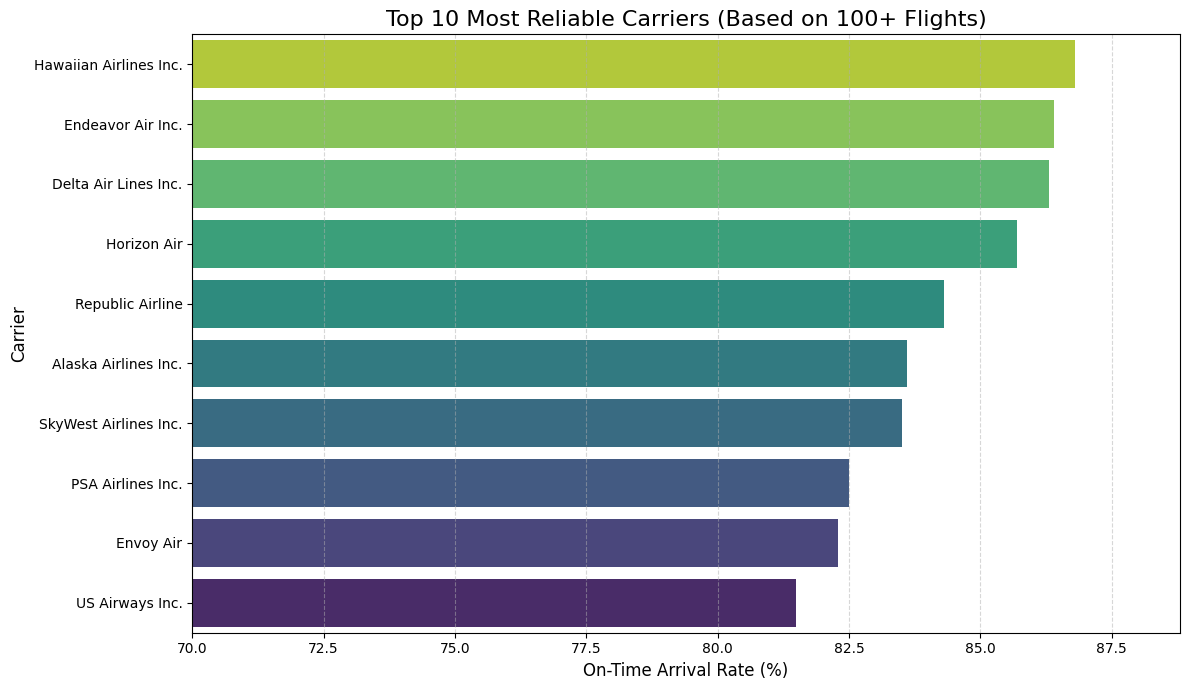

In [561]:
# --- 1.4 Visualization: Top 10 Most Reliable Carriers ---

plt.figure(figsize=(12, 7))

# A horizontal bar plot is excellent for ranking comparisons.
# No 'hue' is needed as the y-axis already represents the carrier categories.
sns.barplot(
    data=top_10_carriers,
    x='on_time_rate',
    y='carrier_name',
    hue='carrier_name',
    palette='viridis_r', # Use a reversed palette for better visual hierarchy
    order=top_10_carriers['carrier_name'] # Ensures plot follows the sorted order
)

# --- Formatting and Labels ---
plt.title(f'Top 10 Most Reliable Carriers (Based on {MIN_FLIGHT_VOLUME}+ Flights)', fontsize=16)
plt.xlabel('On-Time Arrival Rate (%)', fontsize=12)
plt.ylabel('Carrier', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(70, top_10_carriers['on_time_rate'].max() + 2) # Set a dynamic x-limit
plt.tight_layout()
plt.show()

In [562]:
# --- 1.5 Final Business Summary ---

# Pre-calculate key metrics for a clean report.
best_performer_name = top_10_carriers.iloc[0]['carrier_name']
best_performer_rate = top_10_carriers.iloc[0]['on_time_rate']
industry_median_rate = carrier_summary['on_time_rate'].median()
max_rate = carrier_summary['on_time_rate'].max()
min_rate = carrier_summary['on_time_rate'].min()
total_carriers_analyzed = len(carrier_summary)

# Display the key takeaways in a clear, readable format.
print("--- CARRIER RELIABILITY AUDIT: KEY METRICS ---")
print(f"• Best Performer:      {best_performer_name} ({best_performer_rate}%)")
print(f"• Industry Median Rate:  {industry_median_rate:.1f}%")
print(f"• Performance Range:     {min_rate:.1f}% to {max_rate:.1f}%")
print(f"• Total Carriers Analyzed: {total_carriers_analyzed} (with >{MIN_FLIGHT_VOLUME} flights)")

--- CARRIER RELIABILITY AUDIT: KEY METRICS ---
• Best Performer:      Hawaiian Airlines Inc. (86.8%)
• Industry Median Rate:  81.5%
• Performance Range:     74.7% to 86.8%
• Total Carriers Analyzed: 21 (with >100 flights)


## 2. Delay Cost Attribution
#### Business Question: "Management is blaming the weather for recent losses, but Operations suspects internal inefficiencies are the real problem. Breakdown the total minutes lost across the entire fleet to show exactly what share of time is wasted by each specific cause (Weather vs. Carrier vs. System, etc.)."
##### Data Requirements: carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay

In [563]:
# --- 2.1 Data Preparation and Calculation ---

# Define the columns that represent the different causes of delay.
delay_cause_columns = [
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

# Calculate the total sum of delay minutes for each cause across the entire dataset.
# .fillna(0) is used to handle any potential missing values, treating them as zero delay.
total_delay_minutes = df[delay_cause_columns].fillna(0).sum()

# Convert the resulting Series into a DataFrame for easier manipulation.
delay_summary_df = pd.DataFrame(total_delay_minutes, columns=['total_minutes']).sort_values('total_minutes', ascending=False)

# Calculate the percentage contribution of each delay cause to the total.
delay_summary_df['percentage'] = (
    delay_summary_df['total_minutes'] / delay_summary_df['total_minutes'].sum() * 100
).round(1)

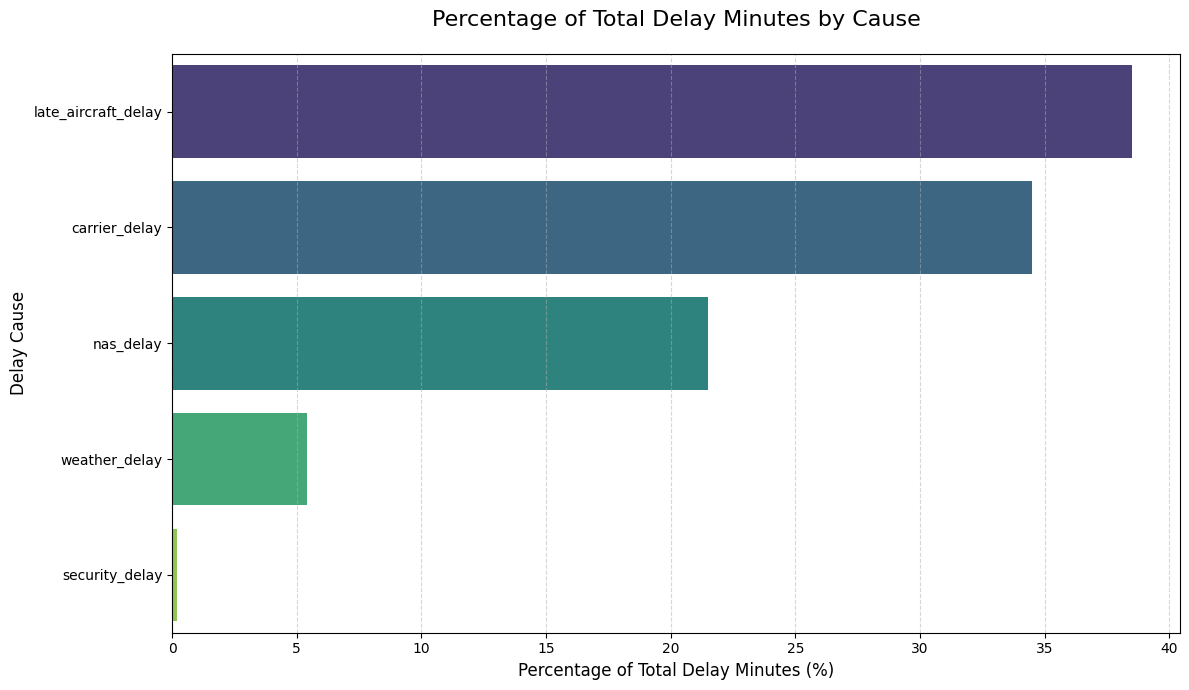

In [564]:
# --- 2.2 Visualization: Delay Breakdown by Cause ---

plt.figure(figsize=(12, 7))

# A horizontal bar plot is ideal for comparing the magnitude of different categories.
# No 'hue' is needed as the y-axis labels already serve this purpose.
sns.barplot(
    data=delay_summary_df,
    x='percentage',
    y=delay_summary_df.index,
    hue=delay_summary_df.index,
    palette='viridis'
)

# --- Formatting and Labels ---
plt.title('Percentage of Total Delay Minutes by Cause', fontsize=16, pad=20)
plt.xlabel('Percentage of Total Delay Minutes (%)', fontsize=12)
plt.ylabel('Delay Cause', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [565]:
# --- 2.3 Final Business Summary and Key Finding ---

# Clean up the index names for a more professional-looking report.
delay_summary_df.index = delay_summary_df.index.str.replace('_', ' ').str.title()

# Display the final summary table.
print("--- DELAY MINUTES BREAKDOWN (DESCENDING ORDER) ---")
display(delay_summary_df)

# Pre-calculate the key metrics to answer the business question directly.
weather_delay_pct = delay_summary_df.loc['Weather Delay', 'percentage']
internal_issues_pct = delay_summary_df.loc[['Carrier Delay', 'Late Aircraft Delay'], 'percentage'].sum()

# Print a concise, data-driven conclusion.
print("\n--- KEY FINDING ---")
print(f"• Weather-related issues account for {weather_delay_pct:.1f}% of all delay minutes.")
print(f"• Combined internal issues (Carrier and Late Aircraft delays) account for {internal_issues_pct:.1f}% of all delay minutes.")

--- DELAY MINUTES BREAKDOWN (DESCENDING ORDER) ---


,total_minutes,percentage
Late Aircraft Delay,240874199.0,38.5
Carrier Delay,215710736.0,34.5
Nas Delay,134371072.0,21.5
Weather Delay,34026171.0,5.4
Security Delay,1144333.0,0.2



--- KEY FINDING ---
• Weather-related issues account for 5.4% of all delay minutes.
• Combined internal issues (Carrier and Late Aircraft delays) account for 73.0% of all delay minutes.


## 3. Seasonal Risk Assessment
#### Business Question: "Marketing wants to launch a 'Guaranteed On-Time' campaign. We need to know which months historically have the highest failure rates so we can avoid running the campaign during those periods. Show me the trend of delay percentages month-over-month."
##### Data Requirements: month, arr_flights, arr_del15

In [566]:
# --- 3.1 Data Preparation and Aggregation ---

# Select only the columns needed for this analysis.
seasonal_df = df[['month', 'arr_flights', 'arr_del15']].copy()

# Group by month and calculate the total number of flights and delayed flights.
monthly_summary = seasonal_df.groupby('month').agg(
    total_flights=('arr_flights', 'sum'),
    total_delays=('arr_del15', 'sum')
).reset_index()

In [567]:
# --- 3.2 Calculate Monthly Performance Rates ---

# Calculate the on-time arrival rate for each month.
monthly_summary['on_time_rate'] = (
    (monthly_summary['total_flights'] - monthly_summary['total_delays']) /
    monthly_summary['total_flights'] * 100
).round(2)

# Calculate the delay rate for context in the final report.
monthly_summary['delay_rate'] = (100 - monthly_summary['on_time_rate']).round(2)

# Add month names for better readability in plots and tables.
monthly_summary['month_name'] = monthly_summary['month'].apply(lambda x: calendar.month_name[int(x)])

# Ensure the data is sorted chronologically by month for the line plot.
monthly_summary = monthly_summary.sort_values('month')

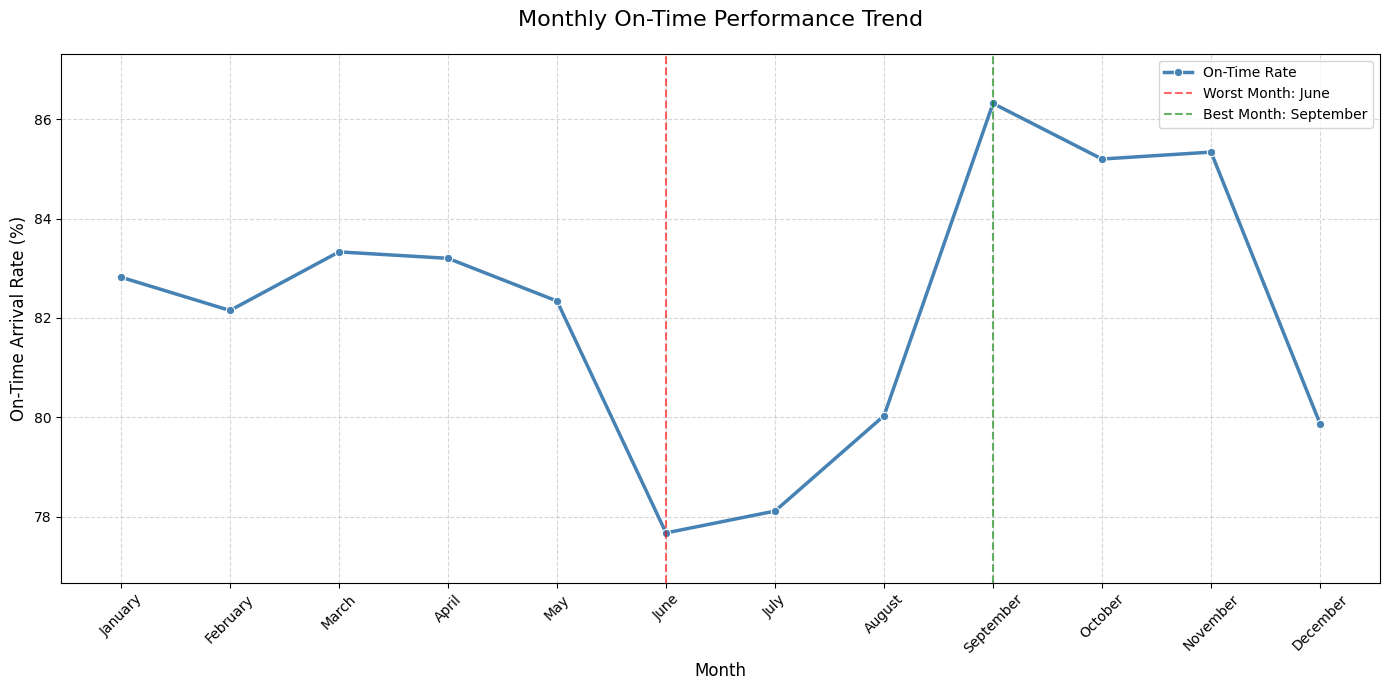

In [568]:
# --- 3.3 Visualization: Monthly On-Time Performance Trend ---

plt.figure(figsize=(14, 7))

# A line plot is ideal for showing trends over a continuous period like time.
sns.lineplot(
    data=monthly_summary,
    x='month_name',
    y='on_time_rate',
    marker='o',
    linewidth=2.5,
    color='steelblue',
    label='On-Time Rate'
)

# --- Formatting and Annotations ---
plt.title('Monthly On-Time Performance Trend', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('On-Time Arrival Rate (%)', fontsize=12)
plt.ylim(monthly_summary['on_time_rate'].min() - 1, monthly_summary['on_time_rate'].max() + 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Highlight the best and worst performing months directly on the chart.
best_month = monthly_summary.loc[monthly_summary['on_time_rate'].idxmax()]
worst_month = monthly_summary.loc[monthly_summary['on_time_rate'].idxmin()]

plt.axvline(x=worst_month['month_name'], color='red', linestyle='--', alpha=0.6, label=f"Worst Month: {worst_month['month_name']}")
plt.axvline(x=best_month['month_name'], color='green', linestyle='--', alpha=0.6, label=f"Best Month: {best_month['month_name']}")

plt.legend()
plt.tight_layout()
plt.show()

In [569]:
# --- 3.4 Final Business Summary and Recommendation ---

print("=" * 70)
print("SEASONAL RISK ASSESSMENT FOR 'GUARANTEED ON-TIME' CAMPAIGN")
print("=" * 70)

# --- High-Risk Months ---
print("\nHIGH-RISK MONTHS (Recommended to AVOID for Campaign):")
print("-" * 50)
worst_months_df = monthly_summary.sort_values('on_time_rate').head(3)
for index, row in worst_months_df.iterrows():
    print(f"• {row['month_name']}: {row['on_time_rate']:.2f}% on-time "
          f"({row['delay_rate']:.2f}% delayed) across {row['total_flights']:,.0f} flights.")

# --- Low-Risk Months ---
print("\nLOW-RISK MONTHS (Recommended to TARGET for Campaign):")
print("-" * 50)
best_months_df = monthly_summary.sort_values('on_time_rate', ascending=False).head(3)
for index, row in best_months_df.iterrows():
    print(f"• {row['month_name']}: {row['on_time_rate']:.2f}% on-time "
          f"({row['delay_rate']:.2f}% delayed) across {row['total_flights']:,.0f} flights.")

# --- Performance Summary ---
print("\nOVERALL PERFORMANCE SUMMARY:")
print("-" * 30)
print(f"• Annual Average On-Time Rate: {monthly_summary['on_time_rate'].mean():.2f}%")
print(f"• Best Month Performance:      {best_month['month_name']} ({best_month['on_time_rate']:.2f}%)")
print(f"• Worst Month Performance:     {worst_month['month_name']} ({worst_month['on_time_rate']:.2f}%)")
print(f"• Max Performance Swing:       {monthly_summary['on_time_rate'].max() - monthly_summary['on_time_rate'].min():.2f} percentage points")

# --- Detailed Monthly Table ---
print("\nDETAILED MONTHLY PERFORMANCE TABLE:")
print("-" * 50)
report_df = monthly_summary[['month_name', 'total_flights', 'total_delays', 'on_time_rate', 'delay_rate']].rename(columns={
    'month_name': 'Month',
    'total_flights': 'Total Flights',
    'total_delays': 'Delayed Flights',
    'on_time_rate': 'On-Time %',
    'delay_rate': 'Delay %'
})
display(report_df.set_index('Month'))

SEASONAL RISK ASSESSMENT FOR 'GUARANTEED ON-TIME' CAMPAIGN

HIGH-RISK MONTHS (Recommended to AVOID for Campaign):
--------------------------------------------------
• June: 77.67% on-time (22.33% delayed) across 4,673,109 flights.
• July: 78.11% on-time (21.89% delayed) across 4,969,560 flights.
• December: 79.87% on-time (20.13% delayed) across 4,104,326 flights.

LOW-RISK MONTHS (Recommended to TARGET for Campaign):
--------------------------------------------------
• September: 86.32% on-time (13.68% delayed) across 3,989,187 flights.
• November: 85.34% on-time (14.66% delayed) across 4,020,092 flights.
• October: 85.20% on-time (14.80% delayed) across 4,179,911 flights.

OVERALL PERFORMANCE SUMMARY:
------------------------------
• Annual Average On-Time Rate: 82.20%
• Best Month Performance:      September (86.32%)
• Worst Month Performance:     June (77.67%)
• Max Performance Swing:       8.65 percentage points

DETAILED MONTHLY PERFORMANCE TABLE:
--------------------------------

,Total Flights,Delayed Flights,On-Time %,Delay %
Month,,,,
January,4215871.0,724133.0,82.82,17.18
February,4222739.0,753694.0,82.15,17.85
March,4954019.0,825911.0,83.33,16.67
April,4505173.0,756885.0,83.20,16.80
May,4550735.0,803518.0,82.34,17.66
June,4673109.0,1043665.0,77.67,22.33
July,4969560.0,1087828.0,78.11,21.89
August,4963589.0,991138.0,80.03,19.97
September,3989187.0,545626.0,86.32,13.68


## 4. Infrastructure Bottleneck Identification
#### Business Question: "We suspect that certain airports are structurally inefficient regardless of the airline flying there. Identify the top airports that suffer specifically from 'National Airspace System' (NAS) related delays, adjusted for their traffic volume."
##### Data Requirements: airport, nas_delay, arr_flights


In [570]:
# --- 4.1 Data Preparation and Aggregation ---

# Select only the columns needed for this analysis.
nas_df = df[['airport', 'nas_delay', 'arr_flights']].copy()

# Group by airport and calculate the total NAS delay minutes and total flight volume.
airport_summary = nas_df.groupby('airport').agg(
    total_nas_delay=('nas_delay', 'sum'),
    total_flights=('arr_flights', 'sum')
).reset_index()

In [571]:
# --- 4.2 Calculate Normalized Metric and Filter ---

# For a fair comparison, we must filter for airports with a meaningful traffic volume.
MIN_FLIGHT_VOLUME = 100
airport_summary = airport_summary[airport_summary['total_flights'] >= MIN_FLIGHT_VOLUME].copy()

# ** KEY METRIC **
# Calculate the average NAS delay minutes per flight. This normalizes the data,
# allowing us to compare large and small airports fairly.
airport_summary['nas_minutes_per_flight'] = (
    airport_summary['total_nas_delay'] / airport_summary['total_flights']
).round(2)

# Sort the airports by our key metric to identify the worst performers.
airport_summary = airport_summary.sort_values('nas_minutes_per_flight', ascending=False).reset_index(drop=True)

In [572]:
# --- 4.3 Identify Top Bottlenecks and Generate Report ---

# Select the top 10 worst-performing airports for our final report.
TOP_N_BOTTLENECKS = 10
top_bottlenecks = airport_summary.head(TOP_N_BOTTLENECKS)

# --- Final Business Report ---
print("=" * 65)
print(f"TOP {TOP_N_BOTTLENECKS} AIRPORT INFRASTRUCTURE BOTTLENECKS (by NAS Delays)")
print("=" * 65)
print(f"Analysis based on airports with over {MIN_FLIGHT_VOLUME} total flights.")
print("-" * 65)

for index, row in top_bottlenecks.iterrows():
    print(f"Rank #{index + 1}: {row['airport']}")
    print(f"  • Average NAS Delay per Flight: {row['nas_minutes_per_flight']:.2f} minutes")
    print(f"  • Total NAS Delay Minutes:      {row['total_nas_delay']:,.0f} minutes")
    print(f"  • Total Flights Analyzed:       {row['total_flights']:,.0f} flights\n")

TOP 10 AIRPORT INFRASTRUCTURE BOTTLENECKS (by NAS Delays)
Analysis based on airports with over 100 total flights.
-----------------------------------------------------------------
Rank #1: EWR
  • Average NAS Delay per Flight: 8.86 minutes
  • Total NAS Delay Minutes:      8,851,586 minutes
  • Total Flights Analyzed:       999,036 flights

Rank #2: LGA
  • Average NAS Delay per Flight: 6.68 minutes
  • Total NAS Delay Minutes:      7,147,880 minutes
  • Total Flights Analyzed:       1,069,447 flights

Rank #3: SFO
  • Average NAS Delay per Flight: 6.10 minutes
  • Total NAS Delay Minutes:      7,644,283 minutes
  • Total Flights Analyzed:       1,253,808 flights

Rank #4: ILG
  • Average NAS Delay per Flight: 6.07 minutes
  • Total NAS Delay Minutes:      1,439 minutes
  • Total Flights Analyzed:       237 flights

Rank #5: UST
  • Average NAS Delay per Flight: 6.03 minutes
  • Total NAS Delay Minutes:      2,498 minutes
  • Total Flights Analyzed:       414 flights

Rank #6: ACY
  • 

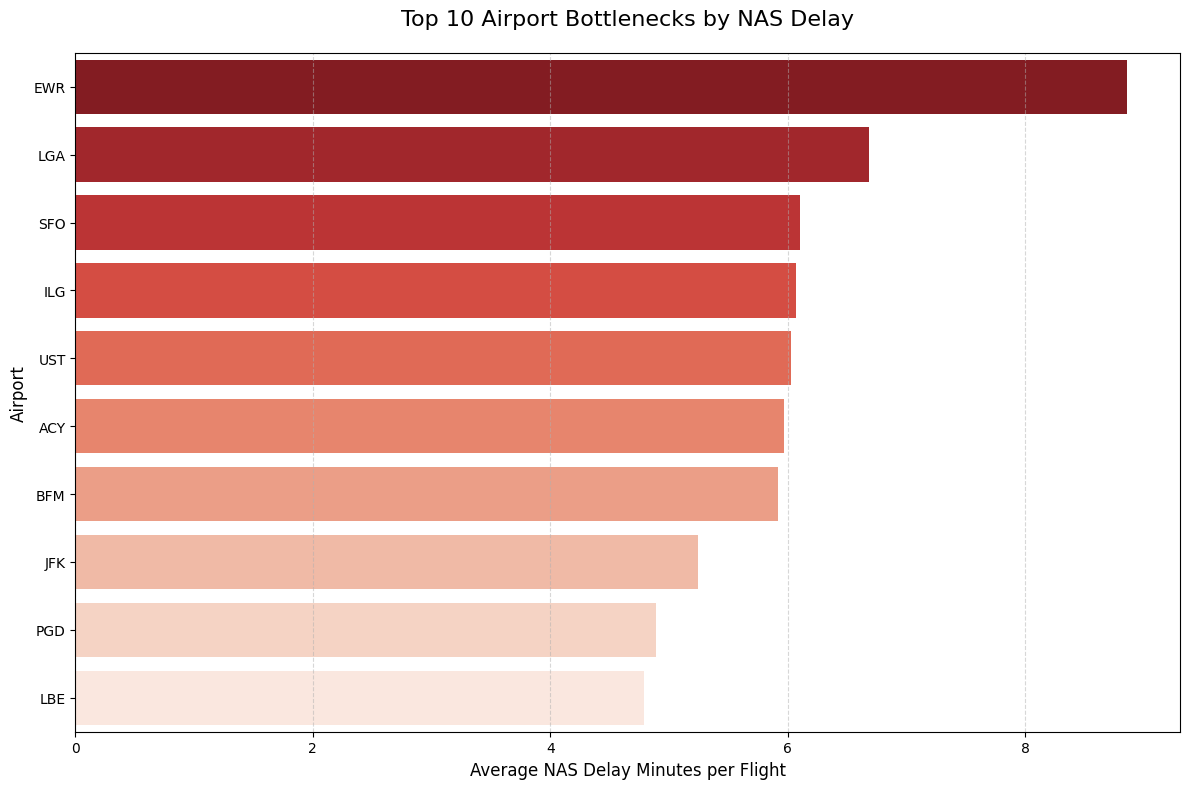

In [573]:
# --- 4.4 Visualization: Top 10 Bottleneck Airports ---

plt.figure(figsize=(12, 8))

# A horizontal bar plot is ideal for ranking. No 'hue' is needed.
sns.barplot(
    data=top_bottlenecks,
    x='nas_minutes_per_flight',
    y='airport',
    hue='airport',
    palette='Reds_r' # A sequential palette is great for "worst-to-least-worst"
)

# --- Formatting and Labels ---
plt.title(f'Top {TOP_N_BOTTLENECKS} Airport Bottlenecks by NAS Delay', fontsize=16, pad=20)
plt.xlabel('Average NAS Delay Minutes per Flight', fontsize=12)
plt.ylabel('Airport', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()